# SAE Probing and Concept Analysis

This notebook investigates the **semantic features discovered by the Sparse Autoencoders (SAEs)** trained on the GPT & Prejudice model.  
While the previous notebook (_SAEs_evaluations) measured reconstruction quality, this stage explores **what each latent dimension actually represents** and how it aligns with interpretable human concepts.

### Objectives
- Extract neuron activations from each trained SAE across a curated set of probing sentences.  
- Identify which latents respond most strongly to certain **concept categories** (e.g., *gender, family, emotion, class, duty*).  
- Quantify feature-concept alignment using metrics such as **activation polarity**, **ΔP**, **average precision (AP)**, and **AUROC**.  
- Visualize and interpret the results to understand how abstract social or narrative themes are encoded layer-wise.

Ultimately, these analyses help reveal how linguistic and thematic patterns, particularly those tied to social and moral structures in Austen’s language—emerge inside model representations.

---

In [1]:
import torch
import json
import numpy as np
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

from sparse_auto_encoder import SparseAutoencoder
from utils.model import load_GPT_model
from sae_probing.extract_latent_activations import exract_latent_activations
from sae_probing.filter_selective_neurons import find_selective_neurons
from sae_probing.neuron_concept_assoc import calculate_neuron_to_concept_assoc
from sae_probing.neuron_concept_mapping import build_neuron_concept_map

### 1. Setup and Data Loading

In [2]:
device = "cpu"

In [3]:
model = load_GPT_model(path="model_896_14_8_256.pth", device=device)

In [4]:
sae_1 = SparseAutoencoder(input_dim=896, hidden_dim=2688).to(device)
sae_1.load_state_dict(torch.load("sae_models/sae_layer1.pth", map_location=torch.device('cpu')))
sae_1.eval();

sae_2 = SparseAutoencoder(input_dim=896, hidden_dim=2688).to(device)
sae_2.load_state_dict(torch.load("sae_models/sae_layer2.pth", map_location=torch.device('cpu')))
sae_2.eval();

sae_3 = SparseAutoencoder(input_dim=896, hidden_dim=3584).to(device)
sae_3.load_state_dict(torch.load("sae_models/sae_layer3.pth", map_location=torch.device('cpu')))
sae_3.eval();

sae_4 = SparseAutoencoder(input_dim=896, hidden_dim=3584).to(device)
sae_4.load_state_dict(torch.load("sae_models/sae_layer4.pth", map_location=torch.device('cpu')))
sae_4.eval();

sae_5 = SparseAutoencoder(input_dim=896, hidden_dim=3584).to(device)
sae_5.load_state_dict(torch.load("sae_models/sae_layer5.pth", map_location=torch.device('cpu')))
sae_5.eval();

sae_6 = SparseAutoencoder(input_dim=896, hidden_dim=4480).to(device)
sae_6.load_state_dict(torch.load("sae_models/sae_layer6.pth", map_location=torch.device('cpu')))
sae_6.eval();

sae_7 = SparseAutoencoder(input_dim=896, hidden_dim=4480).to(device)
sae_7.load_state_dict(torch.load("sae_models/sae_layer7.pth", map_location=torch.device('cpu')))
sae_7.eval();

sae_8 = SparseAutoencoder(input_dim=896, hidden_dim=4480).to(device)
sae_8.load_state_dict(torch.load("sae_models/sae_layer8.pth", map_location=torch.device('cpu')))
sae_8.eval();

### 2. Activation Extraction

Next, we extract the latent features activated inside the SAEs in response to the different sentences included in the **probing dataset**.
The probing data consists of manually selected and labeled prompts designed to activate specific conceptual themes.  
The full dataset is saved in `/datasets/themes_analysis.csv`

For each prompt in the probing dataset:
- The prompt is tokenized and embedded using the GPT model.
- Hidden activations are extracted from the specified transformer layer.  
- These activations are passed through the corresponding SAE to obtain **latent codes**.  
- The latent activations are recorded and stored for later correlation with concept labels.

In [5]:
latents_l1 = exract_latent_activations(model, sae_1, layer=1)
latents_l2 = exract_latent_activations(model, sae_2, layer=2)
latents_l3 = exract_latent_activations(model, sae_3, layer=3)
latents_l4 = exract_latent_activations(model, sae_4, layer=4)
latents_l5 = exract_latent_activations(model, sae_5, layer=5)
latents_l6 = exract_latent_activations(model, sae_6, layer=6)
latents_l7 = exract_latent_activations(model, sae_7, layer=7)
latents_l8 = exract_latent_activations(model, sae_8, layer=8)

✅ Saved sae_probing\activations/latent_activations_l1.pt with latents shape torch.Size([665, 2688]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l2.pt with latents shape torch.Size([665, 2688]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l3.pt with latents shape torch.Size([665, 3584]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l4.pt with latents shape torch.Size([665, 3584]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l5.pt with latents shape torch.Size([665, 3584]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l6.pt with latents shape torch.Size([665, 4480]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l7.pt with latents shape torch.Size([665, 4480]) and 665 ids.
✅ Saved sae_probing\activations/latent_activations_l8.pt with latents shape torch.Size([665, 4480]) and 665 ids.


### 3. Layer-wise Concept Mapping

After extracting all latent features, we identify **which SAE latents (neurons)** align with human-labeled concepts (e.g., *female, male, family, marriage, emotion, class*) in each layer.  

For a given `layer`, the pipeline:

1) **Selects candidate neurons**  
   `find_selective_neurons(layer, activation_threshold=0.5)` screens SAE latents whose activations exceed a threshold on the validation slices.  
   The filter also retains only neurons that fire for at least **5** and at most **150** prompts, ensuring they are neither trivially inactive nor overly generic.  

   **Output:** a compact set of selective neuron IDs saved to  
   `sae_probing/thr_5_0_min_5_max_150/mappings/selective_neuron_ids_l{layer}.pt`.

2) **Computes neuron ↔ concept associations**  
   `calculate_neuron_to_concept_assoc(layer, threshold)` evaluates each selective latent against the probing labels.  
   For each neuron in a given layer, the function measures how strongly it correlates with each concept label using multiple metrics (e.g., Average Precision (AP), AUROC, and ΔP) capturing different aspects of feature–concept alignment.  

   **Output:** detailed association tables saved to  
   `sae_probing/thr_5_0_min_5_max_150/mappings/neuron_label_assoc_l{layer}.csv`.

3) **Builds a compact mapping**  
   `build_neuron_concept_map(layer)` ranks neurons by their AP scores.  
   For each neuron, the top-ranked concept is assigned as the **primary** association, and the second-ranked one as the **secondary** association (if sufficiently strong).  
   To compare their relative strengths, a **polarity score** is computed as:

   \[
   \text{Polarity} = \frac{AP_\text{primary} - AP_\text{secondary}}{AP_\text{primary} + 10^{-9}}
   \]

   This expresses how much stronger the primary association is relative to the secondary, normalized by the primary score.  
   A small constant \(\epsilon = 10^{-9}\) prevents division by zero when the primary AP is extremely small.  
   Neurons are then categorized as:
   - *dominant*: secondary AP ≤ 80% of primary AP  
   - *two-strong*: ≤ 50% margin  
   - *leaning*: ≤ 20% margin  

   **Output:** summary table saved to  
   `sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l{layer}.csv`.

**Print banner**  
Each run reports: the number of token sets (`N`), latent dimension (`H`), window size, threshold used, and how many **selective neurons** were found. The top 5 mappings are also shown as output.

---

#### How to read the table

- `layer` / `neuron`: the SAE layer index and latent unit ID.  
- `primary_concept`, `secondary_concept`: the two concepts most associated with that neuron’s activation pattern.  
- `primary_AP`, `secondary_AP`: **Average Precision** for predicting each concept (higher ⇒ stronger alignment).  
- `polarity_score`: scalar summary of **activation asymmetry** between the top concepts (larger ⇒ clearer preference).  
- `polarity_flag`: qualitative interpretation of the polarity margin:  
  - **dominant:** strong single-concept preference.  
  - **two-strong:** neuron co-activates for two concepts with comparable strength.  
  - **leaning:** mild preference; potentially mixed or context-sensitive feature.

In [6]:
def map_layer_neurons(
    layer,
    activation_threshold=5.0,
    min_count=5,
    max_count=150,
    out_dir_name="results"):

    ROOT_DIR = "sae_probing"
    OUT_DIR_NAME = f"thr_{'_'.join(str(activation_threshold).split('.'))}_min_{min_count}_max_{max_count}"
    OUT_DIR = os.path.join(ROOT_DIR, OUT_DIR_NAME)
    
    if not os.path.isdir(OUT_DIR):
        os.makedirs(OUT_DIR, exist_ok=True)
        os.makedirs(f"{OUT_DIR}/mappings", exist_ok=True)
        os.makedirs(f"{OUT_DIR}/analysis", exist_ok=True)
    
    find_selective_neurons(layer=layer, activation_threshold=activation_threshold, 
                           min_count=min_count, max_count=max_count, 
                           root_dir=ROOT_DIR, out_dir=OUT_DIR)
    
    calculate_neuron_to_concept_assoc(layer=layer, threshold=activation_threshold, root_dir=ROOT_DIR, out_dir=OUT_DIR);

    mappings = build_neuron_concept_map(layer=layer, base_dir=OUT_DIR)
    print(f"✅ Done for layer {layer}")
    print('='*10)
    
    return mappings.head()

In [7]:
map_layer_neurons(layer=1)

Layer 1: N=665 tokensets, H=2688 neurons.
Window [5, 150], thresh=5.0. Selective found: 4
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l1.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l1.csv (44 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l1.csv
✅ Done for layer 1


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,1,236,female,0.288968,marriage,0.250583,0.132834,two-strong
1,1,907,male,0.281076,female,0.259936,0.075212,two-strong
2,1,1406,marriage,0.275057,female,0.238722,0.132101,two-strong
3,1,1829,female,0.240698,male,0.220037,0.085840,two-strong


In [8]:
map_layer_neurons(layer=2)

Layer 2: N=665 tokensets, H=2688 neurons.
Window [5, 150], thresh=5.0. Selective found: 9
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l2.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l2.csv (99 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l2.csv
✅ Done for layer 2


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,2,285,female,0.296231,marriage,0.257890,0.129427,two-strong
1,2,301,male,0.236090,None,NaN,1.000000,dominant
2,2,422,female,0.304699,marriage,0.242622,0.203733,leaning
3,2,999,male,0.254991,family,0.218559,0.142875,two-strong
4,2,1240,male,0.272180,family,0.213962,0.213895,leaning


In [9]:
map_layer_neurons(layer=3)

Layer 3: N=665 tokensets, H=3584 neurons.
Window [5, 150], thresh=5.0. Selective found: 20
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l3.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l3.csv (220 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l3.csv
✅ Done for layer 3


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,3,181,female,0.386466,male,0.307786,0.203590,leaning
1,3,221,marriage,0.247058,family,0.199771,0.191401,two-strong
2,3,293,marriage,0.273580,emotion,0.185834,0.320731,leaning
3,3,344,male,0.272180,family,0.198683,0.270032,leaning
4,3,383,female,0.294968,emotion,0.180950,0.386543,leaning


In [10]:
map_layer_neurons(layer=4)

Layer 4: N=665 tokensets, H=3584 neurons.
Window [5, 150], thresh=5.0. Selective found: 34
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l4.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l4.csv (374 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l4.csv
✅ Done for layer 4


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,4,10,female,0.352208,marriage,0.322754,0.083626,two-strong
1,4,52,male,0.333044,female,0.331162,0.005650,two-strong
2,4,76,marriage,0.392963,duty,0.177979,0.547084,dominant
3,4,117,female,0.241744,male,0.228982,0.052792,two-strong
4,4,208,family,0.349769,male,0.304976,0.128064,two-strong


In [11]:
map_layer_neurons(layer=5)

Layer 5: N=665 tokensets, H=3584 neurons.
Window [5, 150], thresh=5.0. Selective found: 61
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l5.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l5.csv (671 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l5.csv
✅ Done for layer 5


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,5,4,marriage,0.264053,emotion,0.176449,0.331767,leaning
1,5,44,society,0.233149,class,0.154582,0.336982,leaning
2,5,60,female,0.361503,male,0.272109,0.247286,leaning
3,5,210,marriage,0.244495,society,0.204888,0.161994,two-strong
4,5,221,society,0.327070,wealth,0.193297,0.409002,leaning


In [12]:
map_layer_neurons(layer=6)

Layer 6: N=665 tokensets, H=4480 neurons.
Window [5, 150], thresh=5.0. Selective found: 106
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l6.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l6.csv (1166 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l6.csv
✅ Done for layer 6


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,6,2,marriage,0.298232,love,0.286832,0.038226,two-strong
1,6,101,marriage,0.243423,family,0.202482,0.168186,two-strong
2,6,226,male,0.254135,duty,0.130237,0.487528,leaning
3,6,263,society,0.270550,emotion,0.185659,0.313773,leaning
4,6,271,marriage,0.298421,duty,0.143785,0.518183,dominant


In [13]:
map_layer_neurons(layer=7)

Layer 7: N=665 tokensets, H=4480 neurons.
Window [5, 150], thresh=5.0. Selective found: 147
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l7.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l7.csv (1617 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l7.csv
✅ Done for layer 7


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,7,19,female,0.346353,duty,0.130641,0.622811,dominant
1,7,98,marriage,0.295275,female,0.253513,0.141434,two-strong
2,7,101,marriage,0.249885,family,0.206367,0.174153,two-strong
3,7,121,family,0.520283,female,0.347618,0.331868,leaning
4,7,133,marriage,0.251525,society,0.203244,0.191953,two-strong


In [14]:
map_layer_neurons(layer=8)

Layer 8: N=665 tokensets, H=4480 neurons.
Window [5, 150], thresh=5.0. Selective found: 140
-> IDs saved to: sae_probing\thr_5_0_min_5_max_150\mappings\selective_neuron_ids_l8.pt
✅ Associations table saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_label_assoc_l8.csv (1540 rows)
✅ Primary/secondary mapping saved: sae_probing\thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_l8.csv
✅ Done for layer 8


,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
0,8,5,female,0.232870,family,0.224219,0.037150,two-strong
1,8,23,scandal,0.167017,class,0.145863,0.126656,two-strong
2,8,82,emotion,0.191304,class,0.152587,0.202382,leaning
3,8,128,male,0.310567,love,0.133391,0.570491,dominant
4,8,146,male,0.272180,family,0.199877,0.265646,leaning


---

### 4. Visualization 

**Dual-themed neurons**, which are units with both a primary and a secondary concept, show how social and moral categories overlap in the model. They expose relationships rather than single detectors. 

To understand how different concepts relate to each other inside the model we plotted a netwrok graph of all dual-themed neurons identified at each layer. In each graph, nodes denote concepts and edges indicate the number of neurons shared between them, with edge width proportional to the frequency of co-activation normalized per layer.

##### Plotting function:

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

color_map = {
    "female": "#FAD7AC",
    "male": "#cc9290",
    "marriage": "#ed76b3",
    "love": "#CC0000",
    "wealth": "#007FFF",
    "emotion": "#9467bd",
    "family": "#CC6600",
    "duty": "#a4d9f2",
    "scandal and reputation": "#B3B3B3",
    "society": "#67AB9F",
    "neutral": "#e5ced0",
    "class": "#90ee90"
}

def plot_dual_theme_graph_from_csv(
    csv_path, *, color_map=color_map, ax=None, return_fig=False, seed=62,
    layout="spring", spread=1.8, compact=0.7, layer="UNK"
):
    """Reads primary/secondary CSV and plots normalized dual-theme concept graph."""
    df = pd.read_csv(csv_path)
    if "primary_concept" not in df.columns or "secondary_concept" not in df.columns:
        raise ValueError("CSV must contain 'primary_concept' and 'secondary_concept' columns.")
    df = df.dropna(subset=["primary_concept", "secondary_concept"])

    # Build edge list
    edges = []
    for _, row in df.iterrows():
        a = str(row["primary_concept"]).strip(" ,").lower()
        b = str(row["secondary_concept"]).strip(" ,").lower()
        if a and b and a != "unk" and b != "unk":
            edges.append((a, b))

    if not edges:
        fig, axp = plt.subplots(figsize=(6, 3))
        axp.text(0.5, 0.5, "No dual-theme data", ha="center", va="center")
        axp.axis("off")
        fig.tight_layout()
        return (fig, axp) if return_fig else None

    G = nx.MultiGraph()
    G.add_edges_from(edges)

    # Create axes if needed
    created_fig = False
    if ax is None:
        w = compact * 10 + 4
        fig, ax = plt.subplots(figsize=(w, w))
        created_fig = True
    else:
        fig = ax.figure

    # ---- Layout ----
    if layout == "kk":
        pos = nx.kamada_kawai_layout(G)
    else:
        base_k = 0.75 / max(len(G.nodes), 1) ** 0.25
        k = base_k * spread
        pos = nx.spring_layout(G, k=k, seed=seed, iterations=200, scale=1.0)

    # Normalize into [-1, 1] box and then shrink/expand uniformly
    pos = nx.rescale_layout_dict(pos, scale=1.0)
    pos = {n: (x * compact, y * compact) for n, (x, y) in pos.items()}

    # Fix the plot box so figure dimensions don’t change
    ax.set_aspect("equal")
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)

    # ---- Draw ----
    unique_nodes = list(G.nodes())
    node_colors = [color_map.get(node, "#cccccc") for node in unique_nodes]

    edge_weights = {tuple(sorted((u, v))): G.number_of_edges(u, v) for u, v in G.edges()}
    max_w = max(edge_weights.values())
    norm_edges = {k: (0.5 + 19.5 * (w / max_w)) for k, w in edge_weights.items()}

    nx.draw_networkx_nodes(G, pos, node_size=14000, node_color=node_colors, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=20, font_weight="bold", ax=ax)

    drawn = set()
    for (u, v), width in norm_edges.items():
        if (u, v) in drawn:
            continue
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=width, alpha=0.6, ax=ax)
        drawn.add((u, v))

    ax.set_title(f"Layer {layer}", fontsize=25)
    ax.axis("off")
    fig.tight_layout()

    if return_fig:
        return fig, ax

---

**In Layer 1**, the network is extremely sparse, with only a few selective neurons forming a simple backbone around *female*, making it the central node at this depth. This suggests that gender (especially *female*) anchors the earliest structure, with kinship and marriage clustered immediately around it.

**By Layer 4**, the network expands to 16 unique pairings, with a clear cluster around gender and kinship. *Female*, *male*, *family*, and *marriage* dominate as central nodes, connected by multiple overlapping neurons. At the same time, we see the first outward ties to broader social categories: *wealth*, *scandal*, and *society*. Emotion also enters here in tentative form (*emotion–male*, *emotion–female*), layering affective tones onto the gendered core.

**In Layer 8**, the network is densely interconnected. The *gender–family–marriage* cluster remains, but *marriage* becomes the key bridge outward, linking strongly to *society* and *wealth*. Emotional and moral themes also enter, with edges such as *duty–emotion* and *duty–marriage*. Notably, *love–marriage* remains weak, and *scandal* and *class* remain peripheral.

Across all layers, the *gender–family–marriage* triad persists as a stable backbone, growing more interconnected with depth even as its dominance gives way to broader entanglement. Together, these three layers illustrate the progression of dual-themed associations: sparse and focused in the early model, more coherent and structured at mid-depth, and densely interwoven in later layers, where boundaries blur but recurring sub-clusters remain.

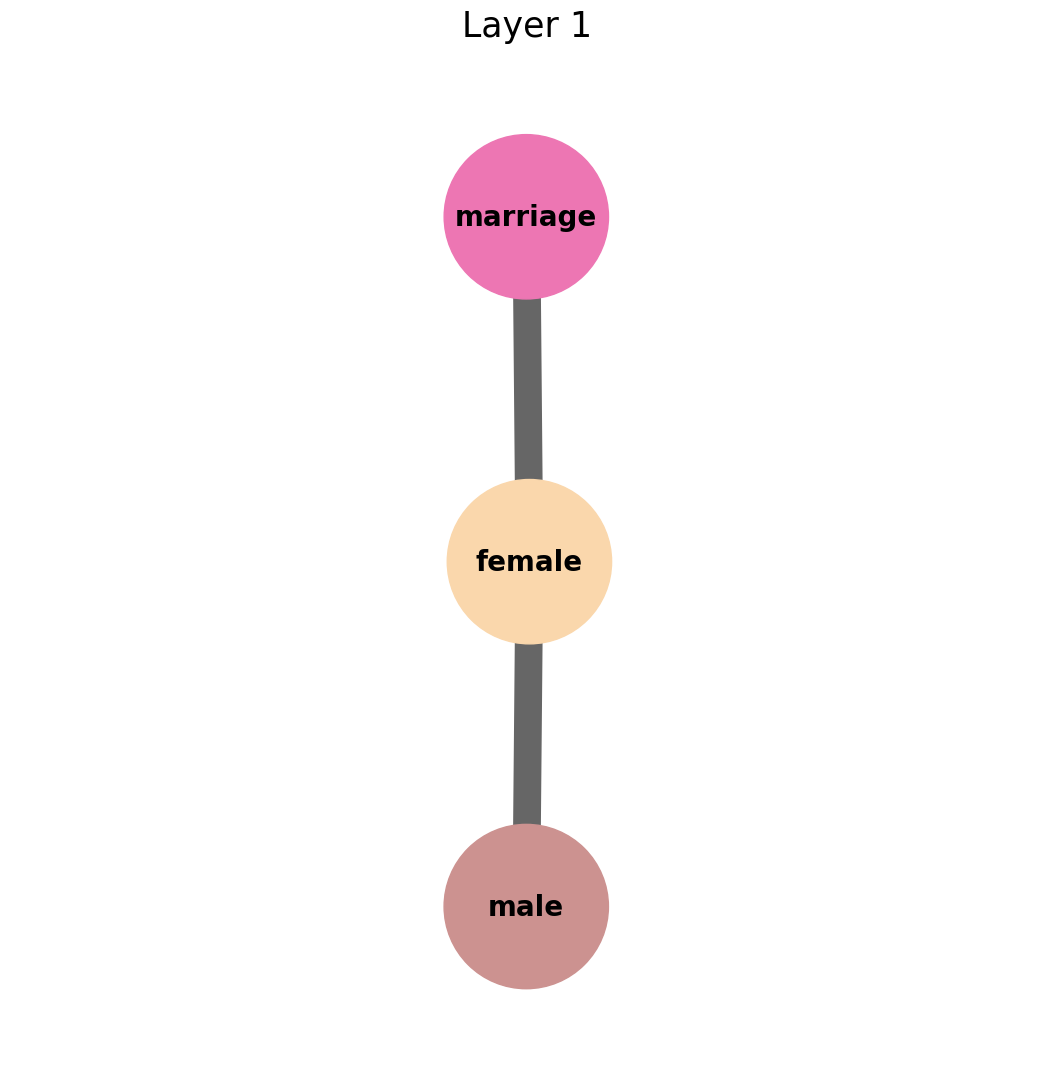

In [16]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l1.csv", layout="kk", spread=1.8, compact=0.7, layer=1)

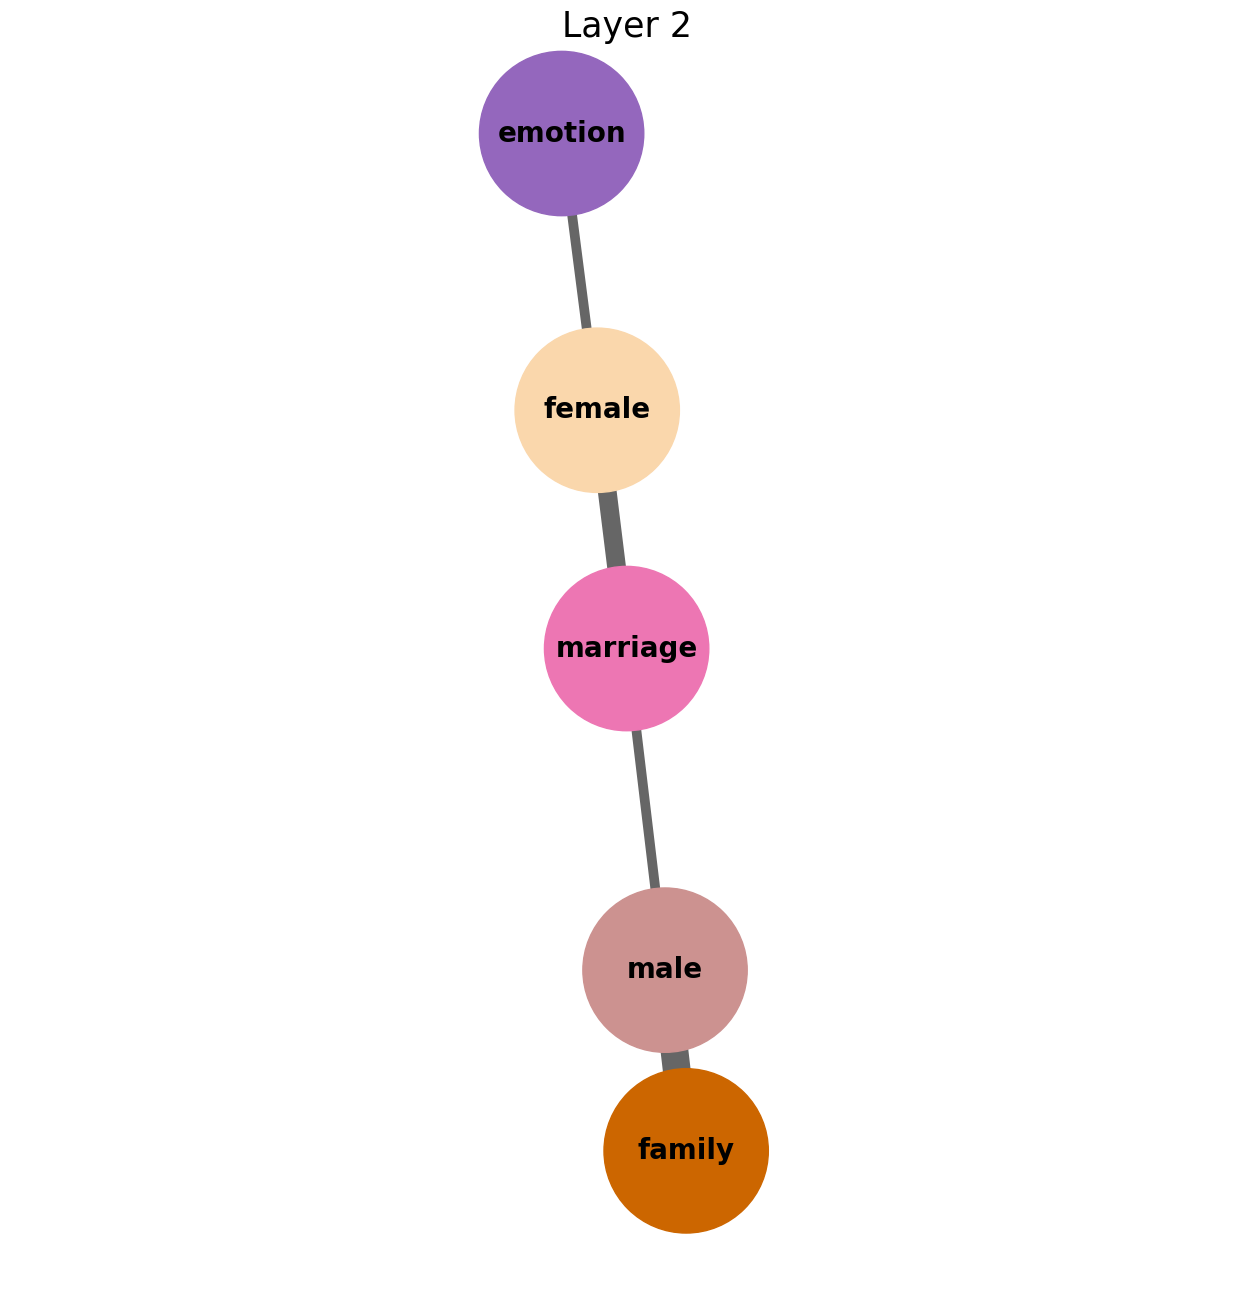

In [17]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l2.csv", spread=7, compact=0.9, layer=2)

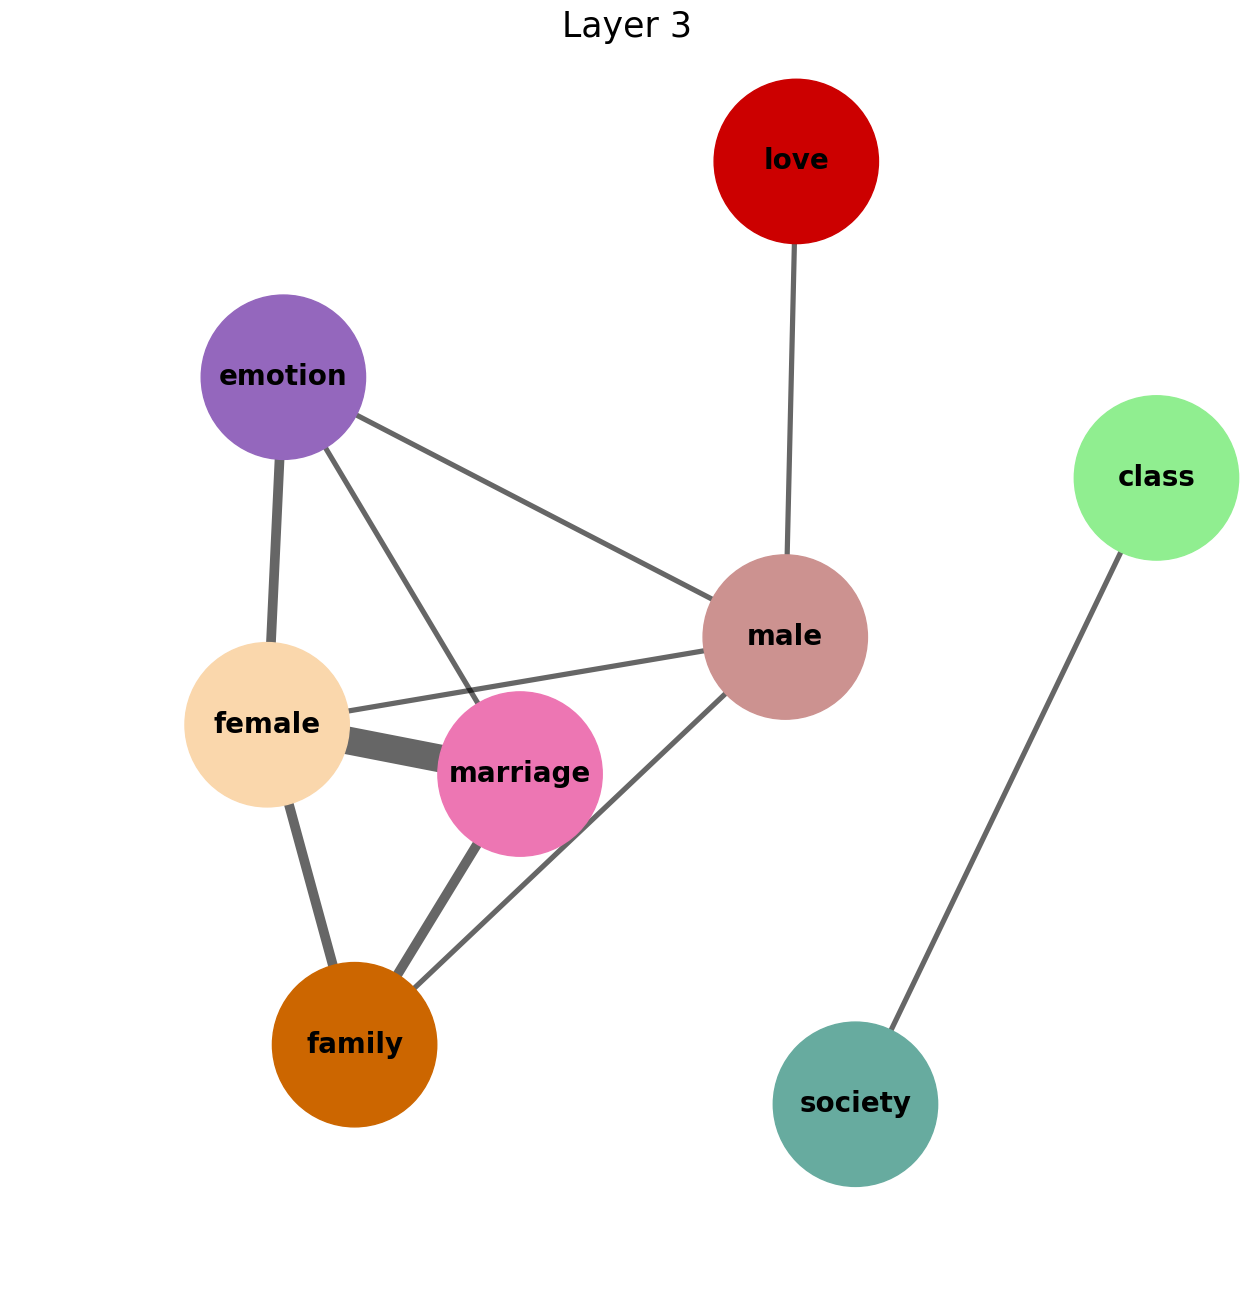

In [18]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l3.csv", spread=18, compact=0.9, layer=3)

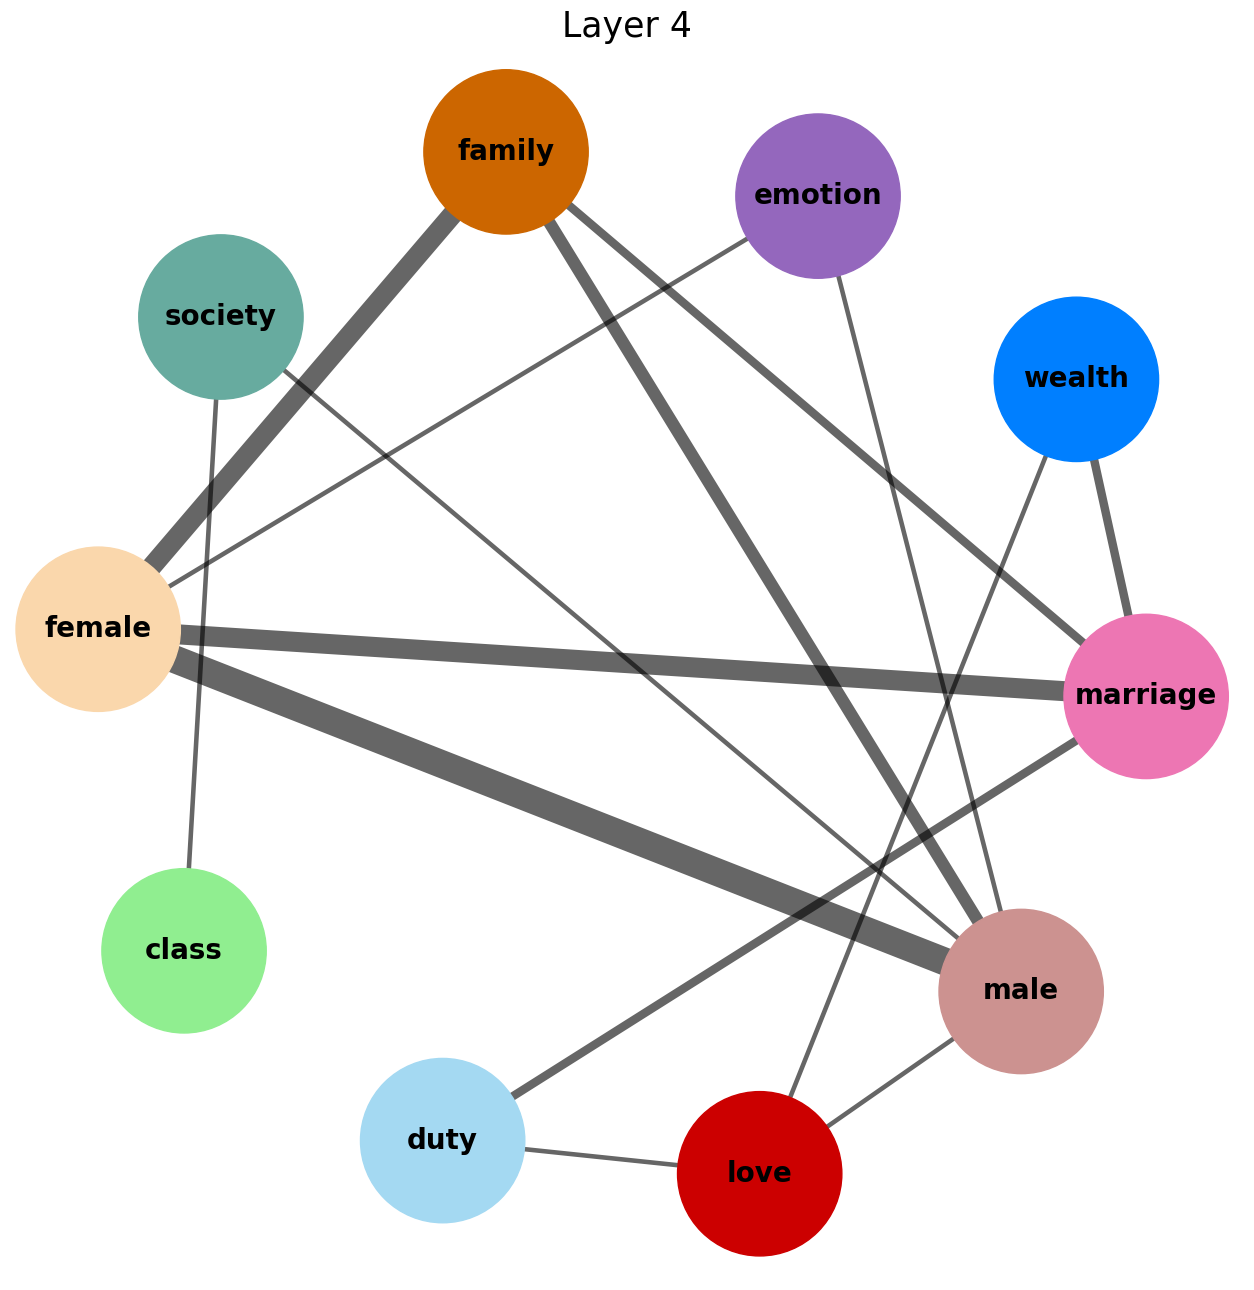

In [19]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l4.csv", spread=100, compact=0.9, layer=4)

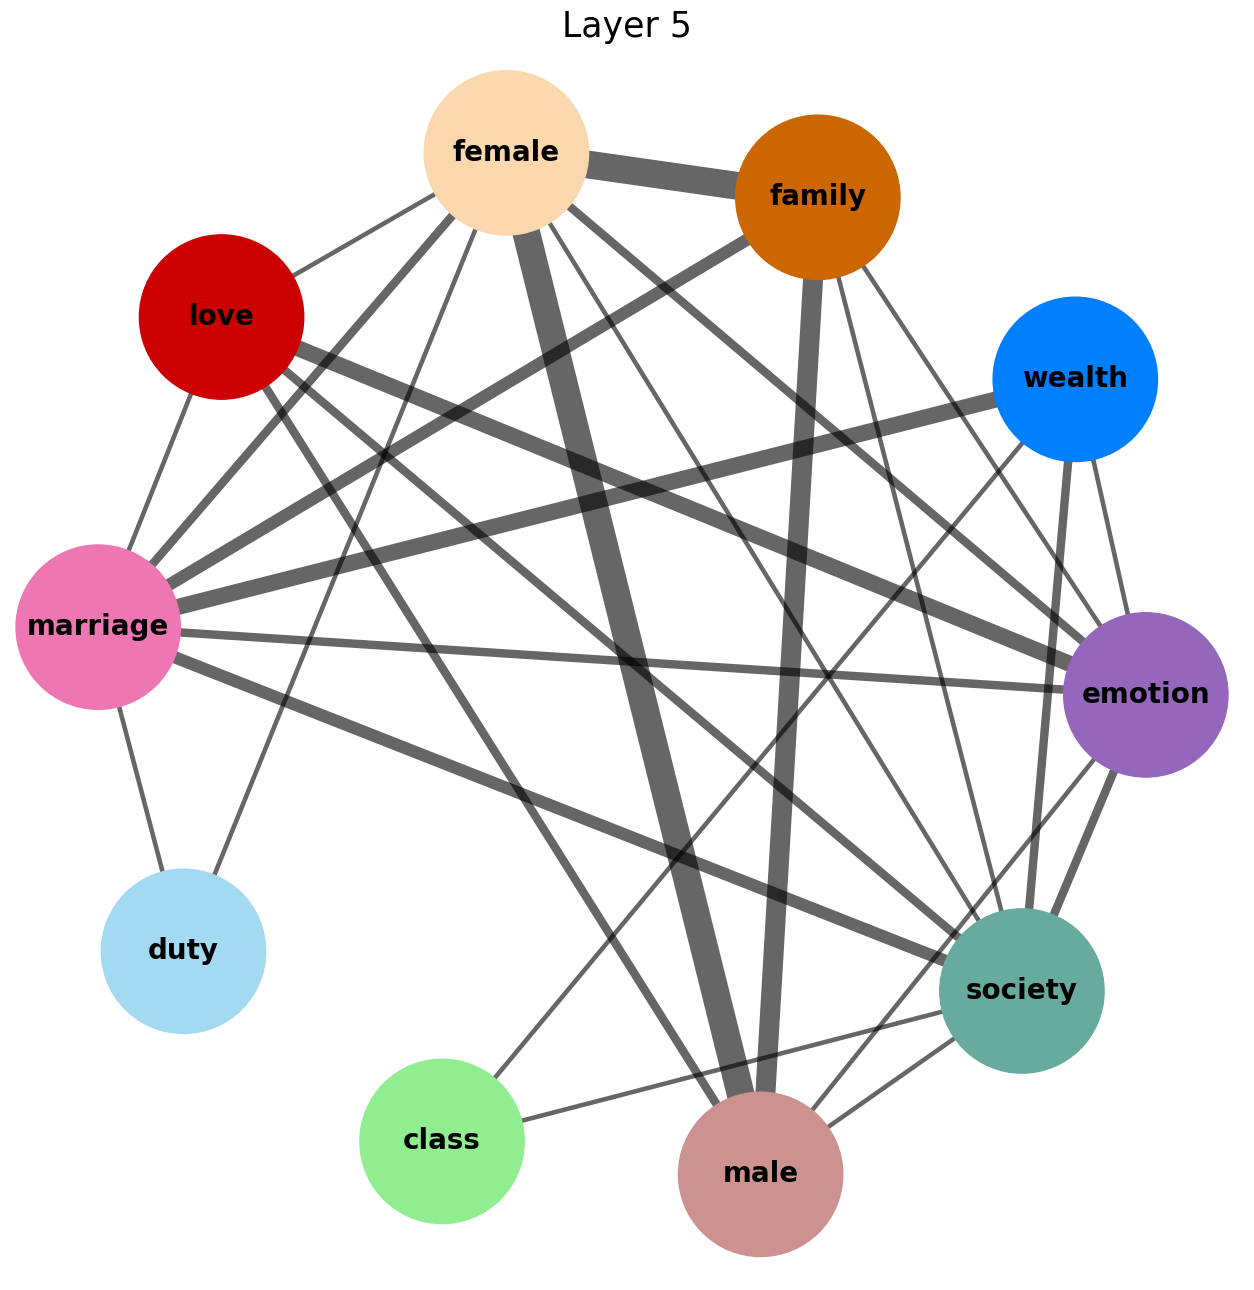

In [20]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l5.csv", spread=100, compact=0.9, layer=5)

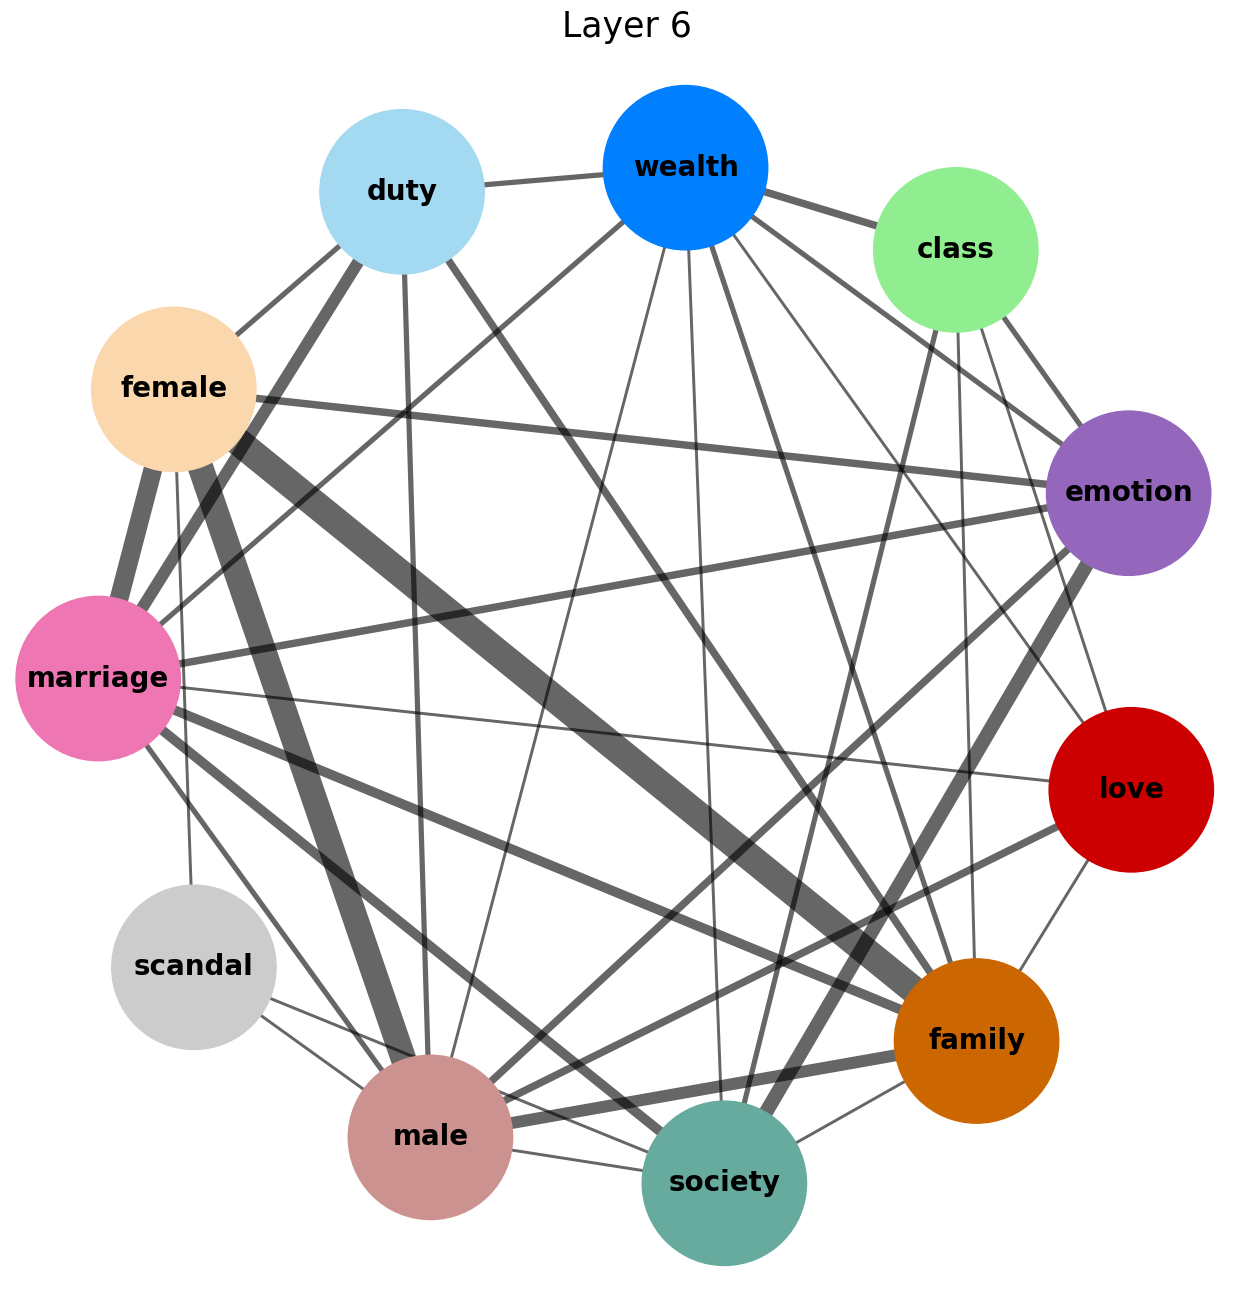

In [21]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l6.csv", spread=100, compact=0.9, layer=6)

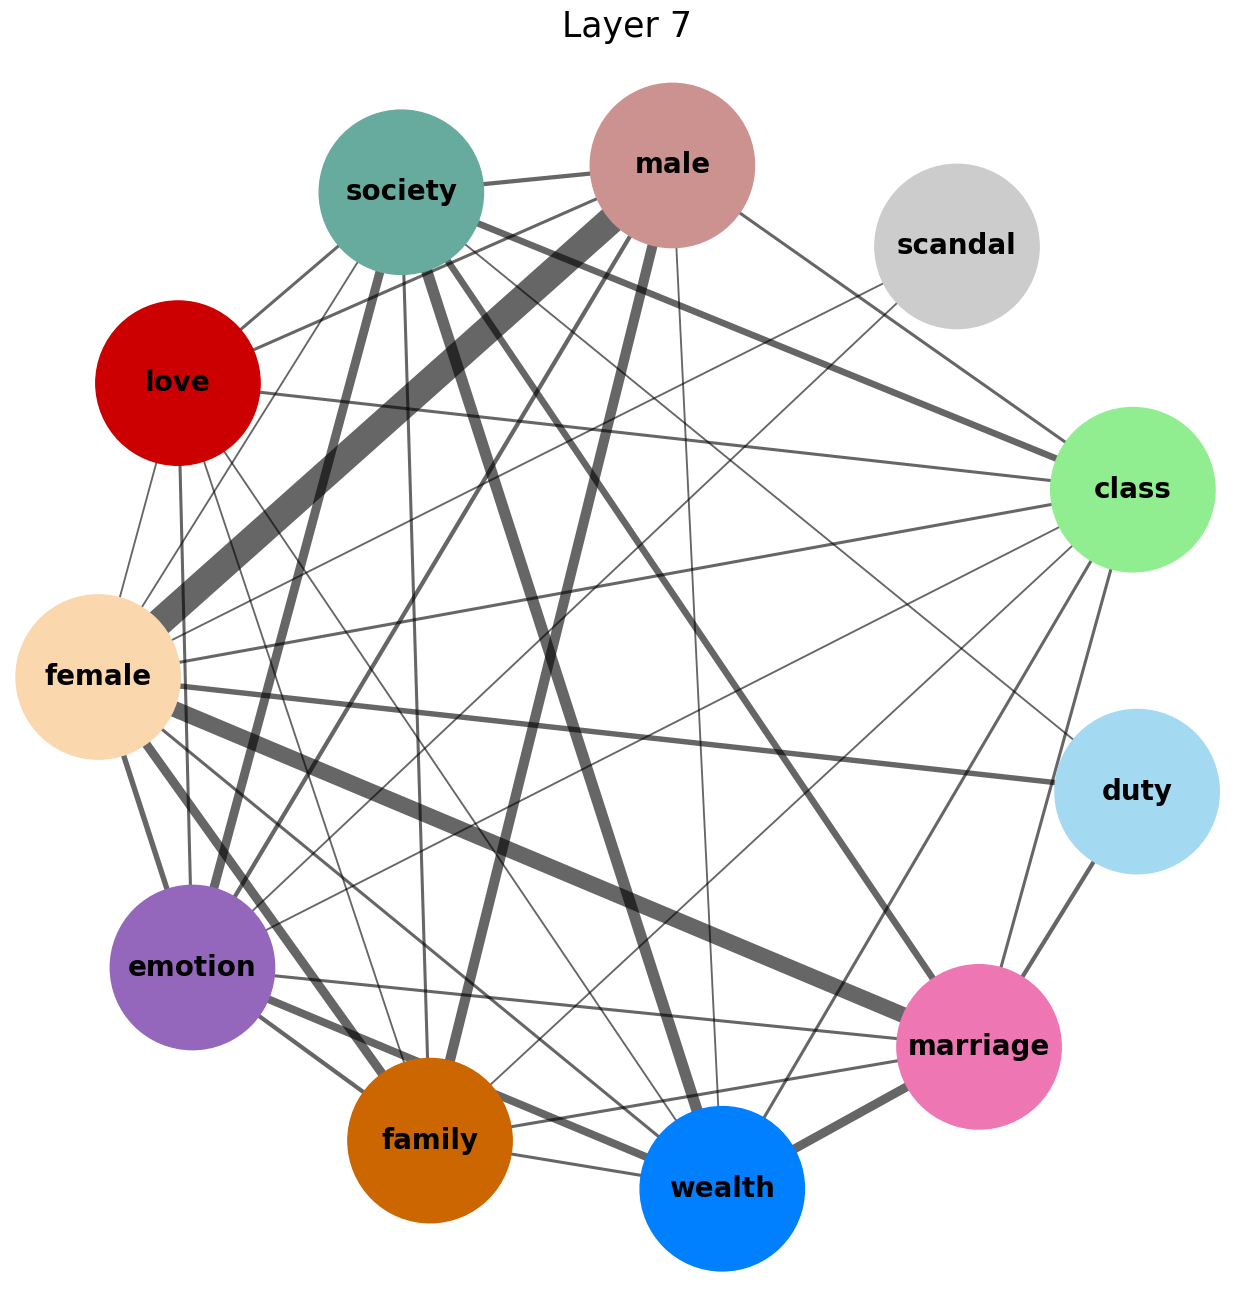

In [22]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l7.csv", spread=100, compact=0.9, layer=7)

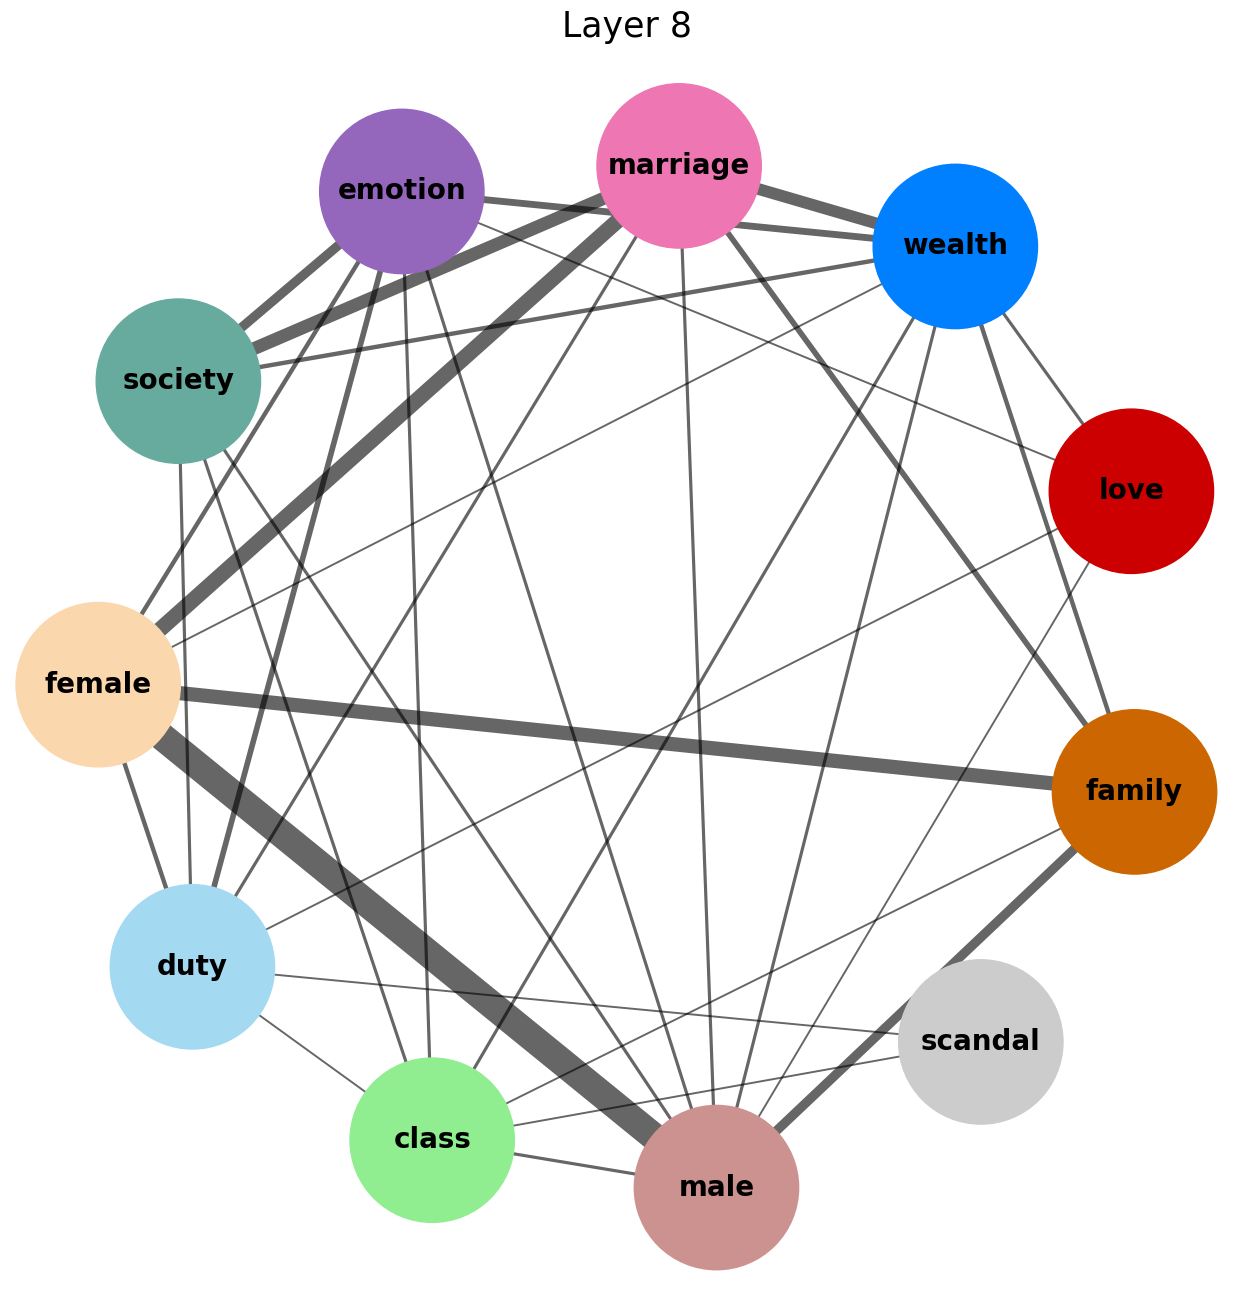

In [23]:
plot_dual_theme_graph_from_csv("sae_probing/thr_5_0_min_5_max_150/mappings/neuron_concept_primary_secondary_l8.csv", spread=100, compact=0.9, layer=8)

---

### Merging all layer output files into one file for later comparisons:

In [24]:
import glob, os
import pandas as pd

base_dir = "sae_probing/thr_5_0_min_5_max_150"

In [25]:
pattern = os.path.join(base_dir, "mappings", "neuron_label_assoc_l*.csv")
files = sorted(glob.glob(pattern))

dfs = []
for f in files:
    df = pd.read_csv(f)
    # make sure each file has a 'layer' column
    if "layer" not in df.columns:
        # try to parse layer number from filename
        layer_num = int(os.path.basename(f).split("_l")[-1].split(".")[0])
        df["layer"] = layer_num
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)
out_path = os.path.join(base_dir, "mappings", "neuron_label_assoc_all_layers.csv")
merged.to_csv(out_path, index=False)

print(f"✅ Merged {len(files)} files into {out_path}, total rows: {len(merged)}")

✅ Merged 8 files into sae_probing/thr_5_0_min_5_max_150\mappings\neuron_label_assoc_all_layers.csv, total rows: 5731


In [26]:
pattern = os.path.join(base_dir, "mappings", "neuron_concept_primary_secondary_l*.csv")
files = sorted(glob.glob(pattern))

dfs = []
for f in files:
    df = pd.read_csv(f)
    # make sure each file has a 'layer' column
    if "layer" not in df.columns:
        # try to parse layer number from filename
        layer_num = int(os.path.basename(f).split("_l")[-1].split(".")[0])
        df["layer"] = layer_num
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)
out_path = os.path.join(base_dir, "mappings", "neuron_concept_primary_secondary_all_layers.csv")
merged.to_csv(out_path, index=False)

print(f"✅ Merged {len(files)} files into {out_path}, total rows: {len(merged)}")

✅ Merged 8 files into sae_probing/thr_5_0_min_5_max_150\mappings\neuron_concept_primary_secondary_all_layers.csv, total rows: 521


---

### 5. Cross-Layer Analysis

In [27]:
!python ./sae_probing/neuron_mapping_analysis.py --base_dir sae_probing/thr_5_0_min_5_max_150


Summary (521 neurons across 8 layers)
 layer  neuron_id primary_concept  primary_AP secondary_concept  secondary_AP  polarity_score polarity_flag
     1        236          female    0.288968          marriage      0.250583        0.132834    two-strong
     1        907            male    0.281076            female      0.259936        0.075212    two-strong
     1       1406        marriage    0.275057            female      0.238722        0.132101    two-strong

Neurons per layer (growth)
 layer  count  growth_vs_prev
     1      4               0
     2      9               5
     3     20              11
     4     34              14
     5     61              27
     6    106              45
     7    147              41
     8    140              -7

Mean primary AP by layer (peak layer)
layer
1    0.271
2    0.306
3    0.307
4    0.313
5    0.295
6    0.287
7    0.280
8    0.277

Peak layer for mean AP: L4 (mean AP = 0.313)

Polarity trends across layers
layer
1    0.106
2   

In [28]:
all_layers_assoc = pd.read_csv(os.path.join(base_dir, "mappings", "neuron_label_assoc_all_layers.csv"))
all_layers_assoc = all_layers_assoc[all_layers_assoc["ΔP"] >= 0]
averages = (
    all_layers_assoc
    .drop(columns=["neuron", "concept"])
    .groupby("layer").mean(numeric_only=True)
)

out_path = os.path.join(base_dir, "analysis", "mean_assoc_metrics_all_layers.csv")
averages.to_csv(out_path)

averages.head()

,AP,AUROC,ΔP,P(fire|1),P(fire|0),lift,label_support,neuron_fires_total
layer,,,,,,,,
1,0.225330,0.508742,0.018181,0.024632,0.006451,2764.951881,133.769231,6.769231
2,0.264821,0.538940,0.054516,0.076332,0.021816,8622.419271,136.200000,21.700000
3,0.242949,0.538656,0.029877,0.045594,0.015717,4366.190721,130.423729,14.491525
4,0.248903,0.555719,0.037239,0.061231,0.023992,1745.028209,126.456311,20.883495
5,0.230053,0.547249,0.031833,0.052811,0.020978,1270.428297,121.320574,18.023923


In [29]:
top_neurons = all_layers_assoc[all_layers_assoc["AP"] >= 0.5].sort_values(by='AP', ascending=False)
top_neurons

,layer,neuron,concept,AP,AUROC,ΔP,P(fire|1),P(fire|0),lift,label_support,neuron_fires_total
2531,6,4328,male,0.726191,0.840268,0.075192,0.075194,0.000002,40003.527552,133,10
3158,7,1773,male,0.652772,0.784598,0.097749,0.097750,0.000002,52003.385832,133,13
1134,5,2246,male,0.626469,0.769242,0.163537,0.165419,0.001882,87.915092,133,23
595,4,2130,male,0.591075,0.751258,0.163537,0.165419,0.001882,87.915092,133,23
276,3,2130,male,0.579555,0.719727,0.045118,0.045120,0.000002,24003.716512,133,6
100,2,1466,male,0.566714,0.740806,0.037599,0.037601,0.000002,20003.763752,133,5
1122,5,2093,female,0.561250,0.727705,0.092109,0.092111,0.000002,47252.913234,152,14
2609,7,121,family,0.520283,0.780605,0.361128,0.445379,0.084251,5.286360,119,99
352,3,3419,female,0.508392,0.716374,0.078951,0.078953,0.000002,40502.979196,152,12


In [30]:
all_mappings = pd.read_csv(os.path.join(base_dir, "mappings", "neuron_concept_primary_secondary_all_layers.csv"))
# target (layer, neuron) pairs
targets = list(zip(top_neurons["layer"], top_neurons["neuron"]))
keys = pd.DataFrame(targets, columns=["layer", "neuron"])

filtered = all_mappings.merge(keys, on=["layer", "neuron"], how="inner").sort_values(by='primary_AP', ascending=False)
# rows NOT in the targets:
# dropped = df.merge(keys, on=["layer","neuron"], how="left", indicator=True).query("_merge=='left_only'").drop(columns="_merge")
filtered

,layer,neuron,primary_concept,primary_AP,secondary_concept,secondary_AP,polarity_score,polarity_flag
6,6,4328,male,0.726191,NaN,NaN,1.000000,dominant
8,7,1773,male,0.652772,family,0.243953,0.626282,dominant
5,5,2246,male,0.626469,family,0.202464,0.676817,dominant
3,4,2130,male,0.591075,family,0.210601,0.643699,dominant
1,3,2130,male,0.579555,love,0.145766,0.748487,dominant
0,2,1466,male,0.566714,NaN,NaN,1.000000,dominant
4,5,2093,female,0.561250,love,0.161198,0.712788,dominant
7,7,121,family,0.520283,female,0.347618,0.331868,leaning
2,3,3419,female,0.508392,family,0.306110,0.397887,leaning
